<a href="https://colab.research.google.com/github/asipnana/ProjectNLP/blob/main/06_xlmroberta_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import json
import random
import warnings
import pickle
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud

import nltk
import kagglehub

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed as hf_set_seed
)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")

# Biar konsisten split shuffle dan train
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
hf_set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.11.0+cu128


In [ ]:
#Upload data nya dari kaggle agar recreateable
#Upload data from kaggle for recreatability

path = kagglehub.dataset_download("jocelyndumlao/prdect-id-indonesian-emotion-classification")
# Check path yang digunakan untuk download dataset from kaggle
print("Path to dataset files:", path)

# Check the path to confirm file and foldername
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))
# Confirm and Load path for data
print(path)
df_raw = pd.read_csv(f'{path}/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv')



100%|██████████| 306k/306k [00:00<00:00, 887kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/versions/1
/root/.cache/kagglehub/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/versions/1/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv
/root/.cache/kagglehub/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/versions/1


In [ ]:
# BASIC Preprocessing
def clean_text(text):
    text = str(text)
    text = text.lower()

    # remove url
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove mention symbol only
    text = re.sub(r"@\w+", "", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df = df_raw[["Customer Review", "Sentiment"]].copy()
# remove exact duplicate and missing values reviews
df = df.dropna(subset=["Customer Review", "Sentiment"])
df = df.drop_duplicates(subset=["Customer Review"]).reset_index(drop=True)

le = LabelEncoder()
df["label"] = le.fit_transform(df["Sentiment"])
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [ ]:
# rename columns
df.rename(
    columns={
        "Customer Review": "review",
        "Sentiment": "sentiment"
    },
    inplace=True
)

df["review_clean"] = df["review"].apply(clean_text)

print("Hasil Light Prepro :")
df[["review", "review_clean"]].head(10)
print(f"Total samples     : {len(df):,}")
print(f"Columns           : {df.columns.tolist()}")

print("\nLabel Distribution")
label_counts = df["sentiment"].value_counts()

print(label_counts.to_dict())

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"Imbalance ratio   : {imbalance_ratio:.2f}x")

print("\nMissing Values")
print(df.isnull().sum())

print("\nSample Data")
display(df.head())

Hasil Light Prepro :
Total samples     : 5,305
Columns           : ['review', 'sentiment', 'label', 'review_clean']

Label Distribution
{'Negative': 2752, 'Positive': 2553}
Imbalance ratio   : 1.08x

Missing Values
review          0
sentiment       0
label           0
review_clean    0
dtype: int64

Sample Data


,review,sentiment,label,review_clean
0,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,1,alhamdulillah berfungsi dengan baik. packaging...
1,"barang bagus dan respon cepat, harga bersaing ...",Positive,1,"barang bagus dan respon cepat, harga bersaing ..."
2,"barang bagus, berfungsi dengan baik, seler ram...",Positive,1,"barang bagus, berfungsi dengan baik, seler ram..."
3,bagus sesuai harapan penjual nya juga ramah. t...,Positive,1,bagus sesuai harapan penjual nya juga ramah. t...
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,1,"barang bagus, pengemasan aman, dapat berfungsi..."


In [ ]:
mapping = {
    cls: idx
    for idx, cls in enumerate(le.classes_)
}

print(mapping)

{'Negative': 0, 'Positive': 1}


In [ ]:
print(df.columns)

Index(['review', 'sentiment', 'label', 'review_clean'], dtype='object')


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

In [ ]:
print("Cek Hasil Splitting")
print(f"Total : {len(df)}")
print(f"Train : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

for name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print(split_df["sentiment"].value_counts(normalize=True) * 100)

Cek Hasil Splitting
Total : 5305
Train : 3713 (70.0%)
Val   : 796 (15.0%)
Test  : 796 (15.0%)

Train
sentiment
Negative    51.871802
Positive    48.128198
Name: proportion, dtype: float64

Validation
sentiment
Negative    51.884422
Positive    48.115578
Name: proportion, dtype: float64

Test
sentiment
Negative    51.884422
Positive    48.115578
Name: proportion, dtype: float64


In [ ]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

# Train -> Train mode, Val -> Early Stopping & Choosing Best Checkpoint , Test -> Evaluation

Sejauh ini INDOBERT dan XLMR BASE diperlakukan sama, setelah ini akan di tokenization sesuai model dan akan berbeda

In [ ]:
X_train = train_df["review_clean"].tolist()
y_train = train_df["label"].tolist()

X_val = val_df["review_clean"].tolist()
y_val = val_df["label"].tolist()

X_test = test_df["review_clean"].tolist()
y_test = test_df["label"].tolist()

print("Dataset Summary")
print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

Dataset Summary
Train : 3,713
Val   : 796
Test  : 796


In [ ]:
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
token_lengths = train_df["review_clean"].apply(
    lambda x: len(tokenizer.tokenize(str(x)))
)

print(token_lengths.describe())

print(f"95th percentile : {token_lengths.quantile(0.95):.0f}")
print(f"99th percentile : {token_lengths.quantile(0.99):.0f}")
print(f"Max             : {token_lengths.max()}")

count    3713.000000
mean       24.609211
std        23.404324
min         1.000000
25%        10.000000
50%        18.000000
75%        31.000000
max       288.000000
Name: review_clean, dtype: float64
95th percentile : 65
99th percentile : 125
Max             : 288


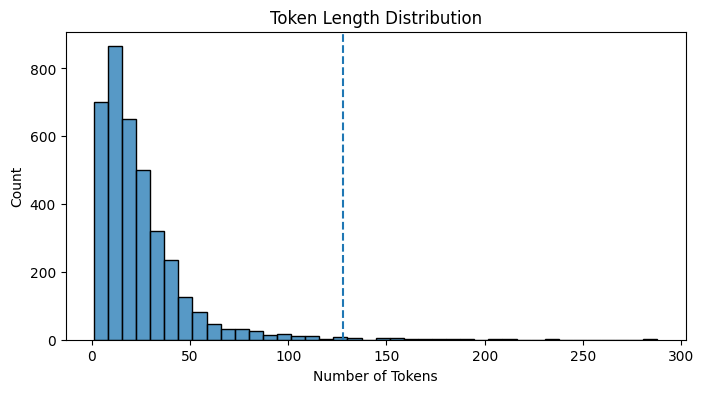

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(token_lengths, bins=40)
plt.axvline(128, linestyle="--")
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.show()

95% ulasan memiliki panjang ≤59 token dan 99% ulasan memiliki panjang ≤107 token. Oleh karena itu, nilai maximum sequence length ditetapkan sebesar 128 token agar sebagian besar ulasan dapat diproses tanpa truncation yang signifikan, sekaligus menjaga efisiensi komputasi selama fine-tuning.

In [ ]:
MAX_LENGTH = 128

In [ ]:
class SentimentDataset(Dataset):
    # Dataset untuk fine-tuning IndoBERT/XLM-R
    # Mengubah teks menjadi input_ids dan attention_mask

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets
train_dataset = SentimentDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = SentimentDataset(
    X_val,
    y_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = SentimentDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

print("Dataset Objects")
print(f"Train : {len(train_dataset):,}")
print(f"Val   : {len(val_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

# Cek Sample
idx = 0

print("Original Review")
print(X_train[idx])

print("\nTrue Label")
print(
    f"{y_train[idx]} "
    f"({le.inverse_transform([y_train[idx]])[0]})"
)

sample = train_dataset[idx]

print("\nInput Shape")
print(sample["input_ids"].shape)

print("\nDecoded Tokens")
print(
    tokenizer.decode(
        sample["input_ids"],
        skip_special_tokens=False
    )
)

print("\nToken List")
tokens = tokenizer.convert_ids_to_tokens(
    sample["input_ids"]
)

print(tokens[:50])

Dataset Objects
Train : 3,713
Val   : 796
Test  : 796
Original Review
kualitas barang bagus, dengan harga yg worth the money...bahan nya halus dan tidak gatal kata istri saya.

True Label
1 (Positive)

Input Shape
torch.Size([128])

Decoded Tokens
<s> kualitas barang bagus, dengan harga yg worth the money...bahan nya halus dan tidak gatal kata istri saya.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>

Token List
['<s>', '▁kualitas', '▁barang', '▁bagus', ',', '▁dengan', '▁harga', '▁yg', '▁worth', '▁the', '▁money'

In [ ]:
# Load Model

MODEL_NAME = "xlm-roberta-base"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(DEVICE)

print(model.config)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}



In [ ]:
# Evaluation Metrics
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    acc = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
# Config untuk training

training_args = TrainingArguments(
    output_dir="./xlmr_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    save_total_limit=2,

    report_to="none",

    seed=SEED
)

In [ ]:
# Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [ ]:
# Kita train model
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.289917,0.176645,0.968593,0.971053,0.963446,0.967235
2,0.117416,0.170581,0.969849,0.945409,0.994778,0.969466
3,0.069434,0.148378,0.976131,0.971503,0.979112,0.975293
4,0.040172,0.132899,0.978643,0.979058,0.976501,0.977778
5,0.022071,0.137805,0.979899,0.976623,0.981723,0.979167


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [ ]:
# Validation
val_metrics = trainer.evaluate(
    val_dataset
)

print(json.dumps(
    val_metrics,
    indent=4
))

{
    "eval_loss": 0.1378045380115509,
    "eval_accuracy": 0.9798994974874372,
    "eval_precision": 0.9766233766233766,
    "eval_recall": 0.9817232375979112,
    "eval_f1": 0.9791666666666666,
    "eval_runtime": 5.7822,
    "eval_samples_per_second": 137.663,
    "eval_steps_per_second": 8.647,
    "epoch": 5.0
}


In [ ]:
# Test Pred

pred_output = trainer.predict(
    test_dataset
)

pred_probs = torch.softmax(
    torch.tensor(pred_output.predictions),
    dim=1
).numpy()

y_pred = np.argmax(
    pred_output.predictions,
    axis=1
)

y_true = pred_output.label_ids

In [ ]:
# Report Classification

print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    Negative       0.97      0.99      0.98       413
    Positive       0.99      0.97      0.98       383

    accuracy                           0.98       796
   macro avg       0.98      0.98      0.98       796
weighted avg       0.98      0.98      0.98       796



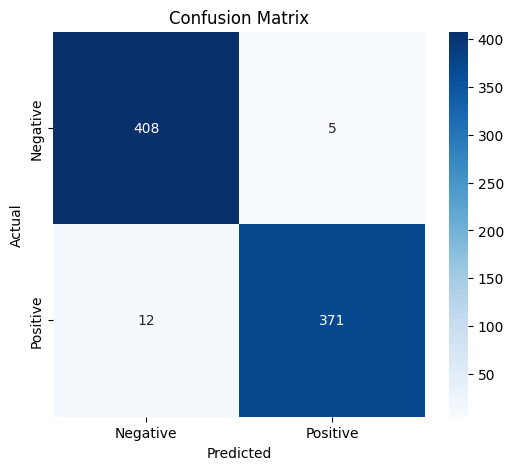

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

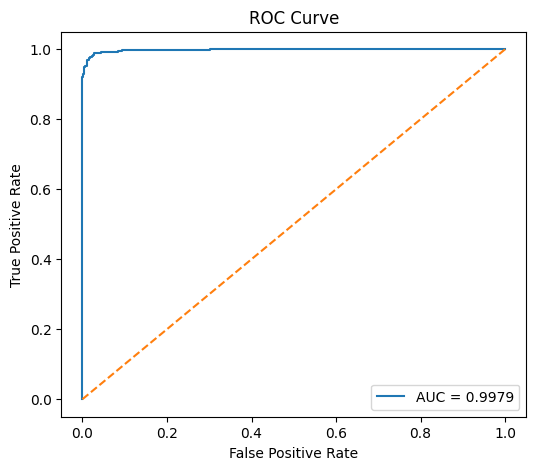

In [ ]:
# Curve ROC

fpr, tpr, _ = roc_curve(
    y_true,
    pred_probs[:, 1]
)

auc_score = roc_auc_score(
    y_true,
    pred_probs[:, 1]
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

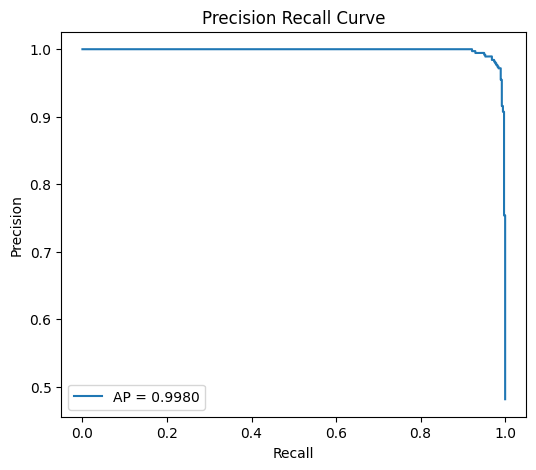

In [ ]:
# Curve Precision Recall (PR Curve)

precision, recall, _ = precision_recall_curve(
    y_true,
    pred_probs[:,1]
)

ap = average_precision_score(
    y_true,
    pred_probs[:,1]
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")
plt.legend()

plt.show()

In [ ]:
# Final Metrics

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Log Loss"
    ],
    "Value": [
        accuracy_score(y_true, y_pred),
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="binary"
        )[0],
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="binary"
        )[1],
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="binary"
        )[2],
        roc_auc_score(
            y_true,
            pred_probs[:,1]
        ),
        log_loss(
            y_true,
            pred_probs
        )
    ]
})

display(results)

,Metric,Value
0,Accuracy,0.978643
1,Precision,0.986702
2,Recall,0.968668
3,F1,0.977602
4,ROC-AUC,0.997907
5,Log Loss,0.135363


In [ ]:
# Simpan Model

SAVE_DIR="./xlmr_sentiment_model"

trainer.save_model(
    SAVE_DIR
)

tokenizer.save_pretrained(
    SAVE_DIR
)

with open(
    f"{SAVE_DIR}/label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(le, f)

print("Model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


In [ ]:
print(model.num_parameters())

278045186


In [ ]:
print(model.config.num_labels)

2


In [ ]:
import os
import time
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_transformer(
    model,
    dataloader,
    y_true,
    model_path=None,
    training_time=None
):

    model.eval()

    predictions = []

    start_inf = time.time()

    with torch.no_grad():
        for batch in dataloader:

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            preds = torch.argmax(outputs.logits, dim=1)

            predictions.extend(preds.cpu().numpy())

    inference_time = time.time() - start_inf

    acc = accuracy_score(y_true, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="weighted"
    )

    params = sum(p.numel() for p in model.parameters())

    size_mb = None
    if model_path:
        size_mb = sum(
            os.path.getsize(os.path.join(dp, f))
            for dp, dn, filenames in os.walk(model_path)
            for f in filenames
        ) / (1024**2)

    return {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Training Time": training_time,
        "Inference Time": inference_time,
        "Parameters": params,
        "Size MB": size_mb
    }

    results = evaluate_transformer(
    model=model,
    dataloader=test_dataloader,
    y_true=y_test,
    model_path="./model"
)

print(results)

      Metric     Value
0   Accuracy  0.978643
1  Precision  0.986702
2     Recall  0.968668
3         F1  0.977602
4    ROC-AUC  0.997907
5   Log Loss  0.135363
